# Assignment 01 - Iris Starter

This notebook loads the Iris dataset from an online source and displays the first 5 rows.

In [2]:
import pandas as pd

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

iris_df = pd.read_csv(url, header=None, names=columns).dropna()
iris_df.to_csv('iris.csv', index=False) #save data locally for upload into hadoop
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


The file iris.csv is then uploaded into hdfs, then all machine learning spark python script runs on unix through Putty

In [3]:
#this cell is a helper function to show images from github
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

def show_github_img(repo_path):
    """Fetches and displays an image directly from your GitHub repo."""
    base_url = "https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Iris_Spark_STQD6324/main/"
    full_url = base_url + repo_path
    
    try:
        response = requests.get(full_url)
        img = Image.open(BytesIO(response.content))
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Error loading image from {full_url}: {e}")

### 1. Logistic Regression
pip install was used to install numpy onto unix hdp2.6.5
logreg_iris.py is saved using Putty

Then function is called using the following command:

spark-submit --master yarn logreg_iris.py

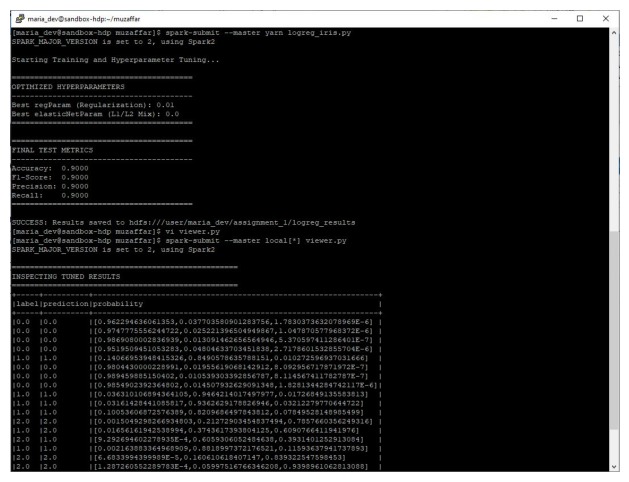

In [4]:
show_github_img("images/logreg_results.JPG")

The optimized hyperparameters found are:
Regularization : 0.01
elasticNetParam (L1/L2 Mix) : 0.0

the results show a 90% accuracy


INSPECTING TUNED RESULTS: Spark_Results/logreg_results


,label,prediction,probability
0,0.0,0.0,"[0.9622946361, 0.0377035809, 1.783e-06]"
1,0.0,0.0,"[0.9747775556, 0.0252213965, 1.0479e-06]"
2,0.0,0.0,"[0.9869080003, 0.0130914627, 5.371e-07]"
3,0.0,0.0,"[0.9519509451, 0.048046337, 2.7179e-06]"
4,1.0,1.0,"[0.1406695395, 0.8490578636, 0.0102725969]"
5,0.0,0.0,"[0.980443, 0.0195561907, 8.093e-07]"
6,0.0,0.0,"[0.9894598852, 0.0105393034, 8.115e-07]"
7,0.0,0.0,"[0.9854902392, 0.0145079326, 1.8281e-06]"
8,1.0,1.0,"[0.0363101069, 0.9464214017, 0.0172684914]"
9,1.0,1.0,"[0.0316142844, 0.9362629179, 0.0321227977]"


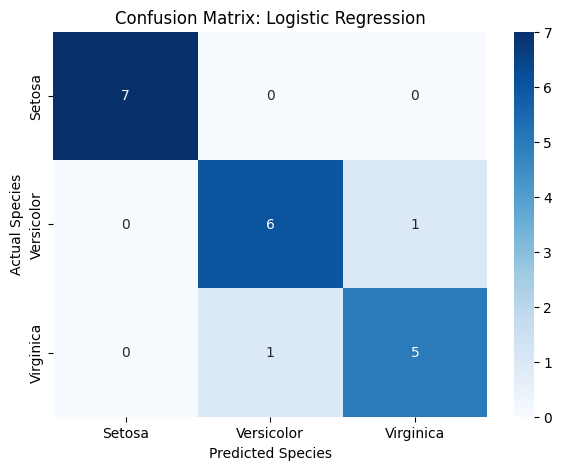

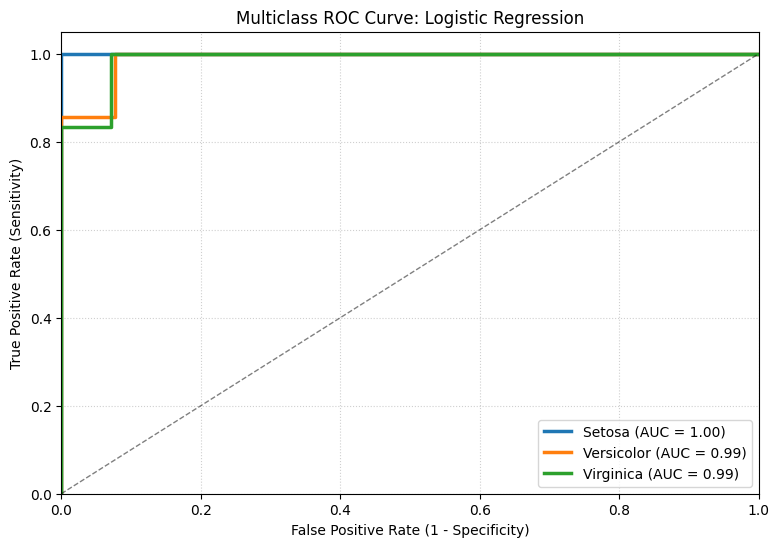

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ======================================================
# 1. FUNCTION DEFINITIONS
# ======================================================

def extract_spark_probabilities(df, col_name='probability'):
    """
    Targets the 'values' list specifically and forces float64 precision.
    This ensures Scikit-Learn generates smooth ROC curves.
    """
    raw_probs = []
    for row in df[col_name]:
        # Spark DenseVector usually loads as a dict with a 'values' key
        if isinstance(row, dict) and 'values' in row:
            raw_probs.append(row['values'])
        # If it's already a list or array
        elif isinstance(row, (list, np.ndarray)):
            raw_probs.append(row)
        else:
            raw_probs.append([0.0, 0.0, 0.0])
            
    # CRITICAL: Force dtype to float64 to ensure smooth curve interpolation
    return np.array(raw_probs, dtype=np.float64)

def plot_confusion_matrix(y_true, y_pred, classes, model_name):
    """Plots a labeled heatmap of the confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual Species')
    plt.xlabel('Predicted Species')
    plt.show()

def plot_multiclass_roc(y_true, y_probs, classes, model_name):
    """Plots multiclass ROC curves using the raw probability values."""
    # Binarize labels for 1-vs-All logic (Required for multiclass ROC)
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    n_classes = len(classes)
    
    plt.figure(figsize=(9, 6))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Professional color palette
    
    for i in range(n_classes):
        # We pass the i-th column of probabilities (floats) for the i-th species
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=2.5, 
                 label=f'{classes[i]} (AUC = {roc_auc:0.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title(f'Multiclass ROC Curve: {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# ======================================================
# 2. MAIN EXECUTION
# ======================================================

# Define your local folder path (Change this to switch models)
results_path = "Spark_Results/logreg_results"
species_labels = ['Setosa', 'Versicolor', 'Virginica']

try:
    # A. Load Parquet via pyarrow
    table = pq.read_table(results_path)
    df_results = table.to_pandas()
    
    # B. Extract Data for Calculations
    y_true = df_results['label'].values
    y_pred = df_results['prediction'].values
    y_probs = extract_spark_probabilities(df_results)

    # C. FORMAT FOR TABLE DISPLAY (Mimics Unix/Spark terminal output)
    display_df = df_results[['label', 'prediction']].copy()
    # Format probabilities as clean lists for the visual table
    display_df['probability'] = [list(np.round(p, 10)) for p in y_probs]

    print(f"\n==================================================")
    print(f"INSPECTING TUNED RESULTS: {results_path}")
    print(f"==================================================")
    
    # Render the interactive table
    display(display_df.head(20)) 
    
    print(f"==================================================\n")

    # D. Visualize Graphs
    # Confusion Matrix uses hard predictions (y_pred)
    plot_confusion_matrix(y_true, y_pred, species_labels, "Logistic Regression")
    
    # ROC Curve uses raw probability decimals (y_probs) for a smooth curve
    plot_multiclass_roc(y_true, y_probs, species_labels, "Logistic Regression")

except Exception as e:
    print(f"An error occurred: {e}")

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ======================================================
# 1. FUNCTION DEFINITIONS
# ======================================================

def extract_spark_probabilities(df, col_name='probability'):
    """
    Targets the 'values' list specifically to get raw decimals for smooth ROC curves.
    """
    raw_probs = []
    for row in df[col_name]:
        # Spark Vector format: {'type': 1, 'size': 3, 'values': [0.9, 0.05, 0.05]}
        if isinstance(row, dict) and 'values' in row:
            raw_probs.append(row['values'])
        # Handle cases where it might already be a list or array
        elif isinstance(row, (list, np.ndarray)):
            raw_probs.append(row)
        else:
            raw_probs.append([0.0, 0.0, 0.0])
            
    return np.array(raw_probs)

def plot_confusion_matrix(y_true, y_pred, classes, model_name):
    """Plots a labeled heatmap of the confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual Species')
    plt.xlabel('Predicted Species')
    plt.show()

def plot_prediction_scatter(y_true, y_pred, model_name):
    """
    Creates a scatter plot comparing Actual labels vs Predicted labels.
    Correct predictions overlap, while errors appear as separate points.
    """
    plt.figure(figsize=(10, 5))
    
    # Create an index for the x-axis (sample number)
    samples = np.arange(len(y_true))
    
    # Plot Actual Values
    plt.scatter(samples, y_true, color='blue', alpha=0.5, s=100, label='Actual', marker='o')
    
    # Plot Predicted Values
    plt.scatter(samples, y_pred, color='red', alpha=0.8, s=30, label='Predicted', marker='x')
    
    # Add connecting lines to highlight gaps (errors)
    for i in range(len(y_true)):
        if y_true[i] != y_pred[i]:
            plt.vlines(i, y_true[i], y_pred[i], colors='red', linestyles='dotted', alpha=0.5)

    plt.yticks([0, 1, 2], ['Setosa', 'Versicolor', 'Virginica'])
    plt.xlabel('Sample Index')
    plt.ylabel('Species Classification')
    plt.title(f'Prediction Accuracy Scatter: {model_name}')
    plt.legend(loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

def plot_multiclass_roc(y_true, y_probs, classes, model_name):
    """Plots multiclass ROC curves using the raw probability values."""
    # Binarize labels for 1-vs-All logic
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    n_classes = len(classes)
    
    plt.figure(figsize=(9, 6))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green
    
    for i in range(n_classes):
        # We pass the i-th column of y_probs for the i-th class
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=2.5, 
                 label=f'{classes[i]} (AUC = {roc_auc:0.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title(f'Multiclass ROC Curve: {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()




INSPECTING LOGREG RESULTS (Merged with CSV)


,label,prediction,probability
0,0.0,0.0,"[0.9623, 0.0377, 0.0]"
1,0.0,0.0,"[0.9748, 0.0252, 0.0]"
2,0.0,0.0,"[0.9869, 0.0131, 0.0]"
3,0.0,0.0,"[0.952, 0.048, 0.0]"
4,1.0,1.0,"[0.1407, 0.8491, 0.0103]"
5,0.0,0.0,"[0.9804, 0.0196, 0.0]"
6,0.0,0.0,"[0.9895, 0.0105, 0.0]"
7,0.0,0.0,"[0.9855, 0.0145, 0.0]"
8,1.0,1.0,"[0.0363, 0.9464, 0.0173]"
9,1.0,1.0,"[0.0316, 0.9363, 0.0321]"


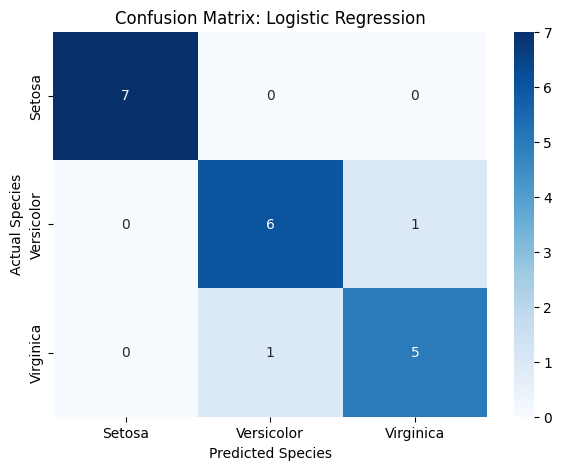

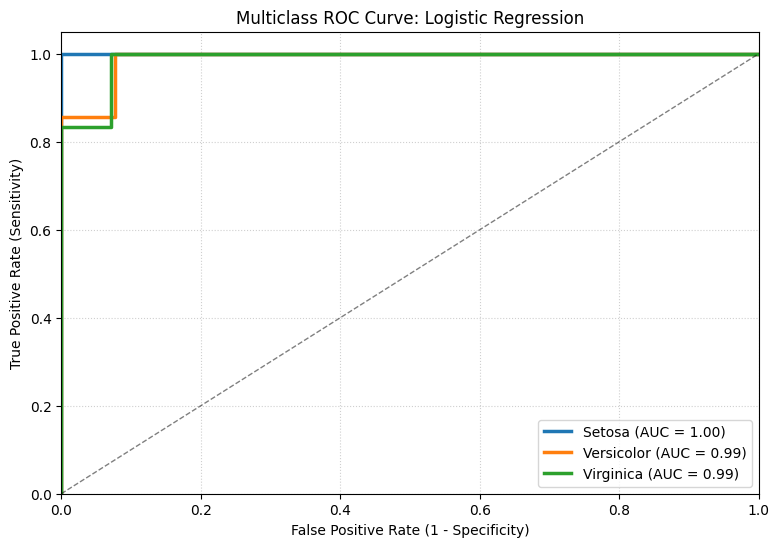

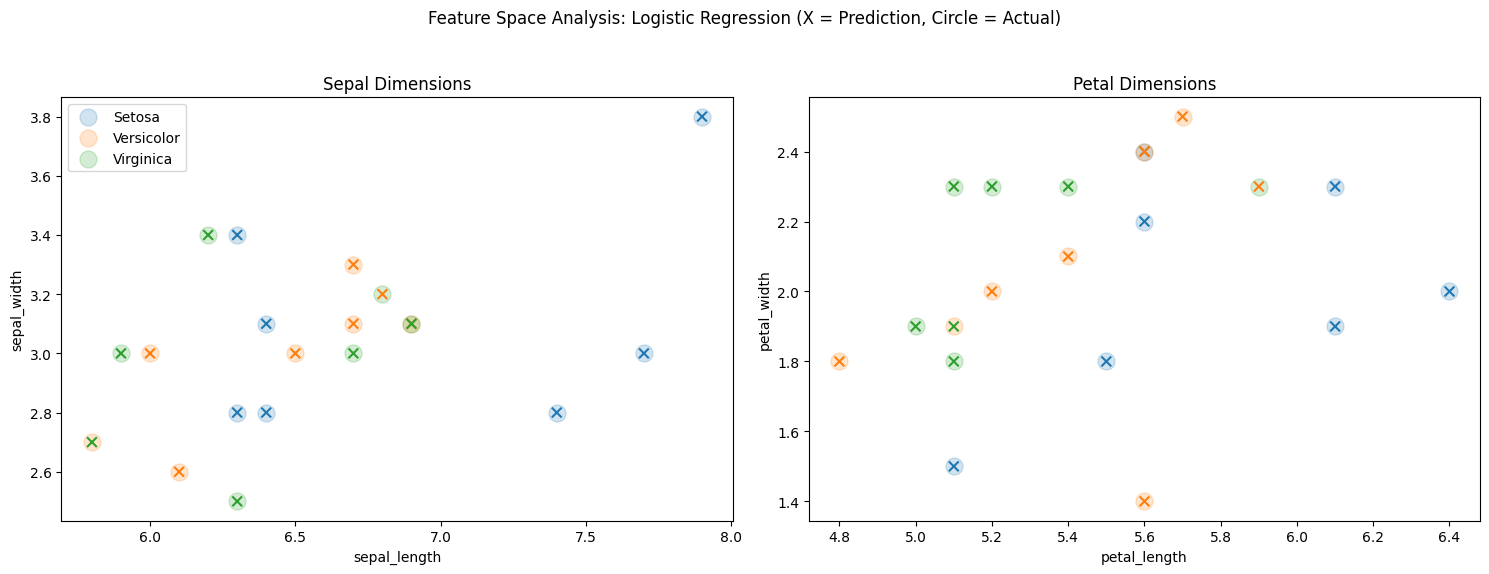

In [40]:
# ======================================================
# 2. Logistic Regression Result Analysis
# ======================================================

results_path = "Spark_Results/logreg_results"
csv_path = "iris.csv"
species_labels = ['Setosa', 'Versicolor', 'Virginica']

try:
    # A. Load Spark Results and Merge with CSV Features
    df_final, feat_names = load_and_merge_data(results_path, csv_path)
    
    # B. Extract Probability Array for ROC
    y_probs = extract_spark_probabilities(df_final)
    y_true = df_final['label'].values
    y_pred = df_final['prediction'].values

    # C. UNIX-STYLE TABLE DISPLAY
    display_df = df_final[['label', 'prediction']].copy()
    display_df['probability'] = [list(np.round(p, 4)) for p in y_probs]
    
    print(f"\n==================================================")
    print(f"INSPECTING LOGREG RESULTS (Merged with CSV)")
    print(f"==================================================")
    display(display_df.head(15)) 
    print(f"==================================================\n")

    # D. Visualize Graphs
    plot_confusion_matrix(y_true, y_pred, species_labels, "Logistic Regression")
    plot_multiclass_roc(y_true, y_probs, species_labels, "Logistic Regression")
    plot_iris_feature_scatter(df_final, feat_names, "Logistic Regression")

except Exception as e:
    print(f"An error occurred: {e}")


INSPECTING TUNED RESULTS: Spark_Results/dtree_result_2


,label,prediction,probability
0,0.0,0.0,"[1.0, 0.0, 0.0]"
1,0.0,0.0,"[1.0, 0.0, 0.0]"
2,0.0,0.0,"[1.0, 0.0, 0.0]"
3,0.0,0.0,"[1.0, 0.0, 0.0]"
4,1.0,2.0,"[0.0, 0.0, 1.0]"
5,0.0,0.0,"[1.0, 0.0, 0.0]"
6,0.0,0.0,"[1.0, 0.0, 0.0]"
7,0.0,0.0,"[1.0, 0.0, 0.0]"
8,1.0,1.0,"[0.0, 1.0, 0.0]"
9,1.0,1.0,"[0.0, 1.0, 0.0]"


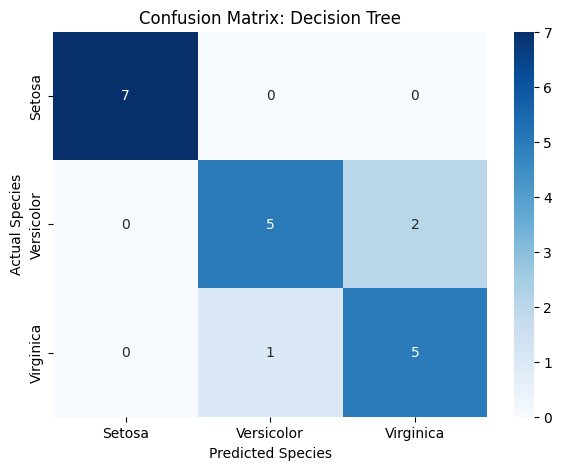

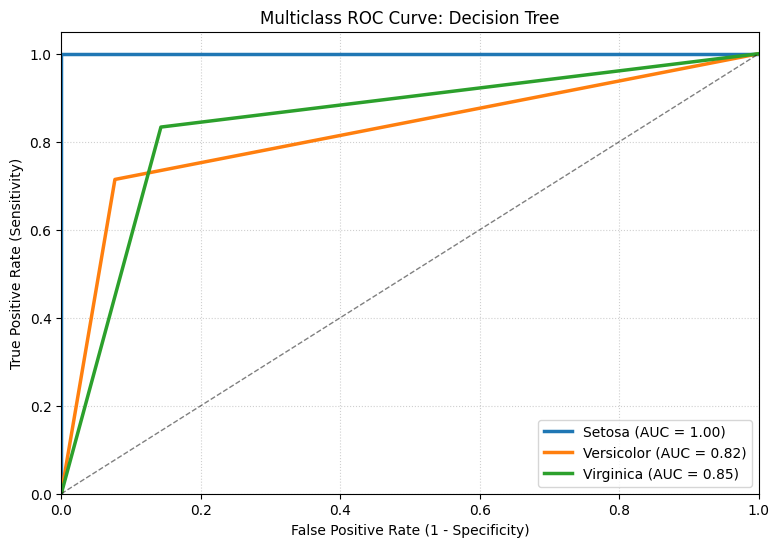

In [29]:
# ======================================================
# 3. Decision Tree Result Analysis
# ======================================================

# Define your local folder path (Updated for DTree)
results_path = "Spark_Results/dtree_result_2"
species_labels = ['Setosa', 'Versicolor', 'Virginica']

try:
    # A. Load Parquet
    table = pq.read_table(results_path)
    df_results = table.to_pandas()
    
    # B. Extract Data for Calculations
    y_true = df_results['label'].values
    y_pred = df_results['prediction'].values
    y_probs = extract_spark_probabilities(df_results)

    # C. FORMAT FOR TABLE DISPLAY
    # We create a clean version for the table view
    display_df = df_results[['label', 'prediction']].copy()
    
    # Format probabilities to a list of floats
    display_df['probability'] = [list(np.round(p, 10)) for p in y_probs]

    print(f"\n==================================================")
    print(f"INSPECTING TUNED RESULTS: {results_path}")
    print(f"==================================================")
    
    # Renders the interactive table
    display(display_df.head(20)) 
    
    print(f"==================================================\n")

    # D. Visualize Graphs
    plot_confusion_matrix(y_true, y_pred, species_labels, "Decision Tree")
    plot_multiclass_roc(y_true, y_probs, species_labels, "Decision Tree")

except Exception as e:
    print(f"An error occurred: {e}")


INSPECTING TUNED RESULTS: Spark_Results/rf_result_2


,label,prediction,probability
0,0.0,0.0,"[1.0, 0.0, 0.0]"
1,0.0,0.0,"[1.0, 0.0, 0.0]"
2,0.0,0.0,"[1.0, 0.0, 0.0]"
3,0.0,0.0,"[1.0, 0.0, 0.0]"
4,1.0,1.0,"[0.0, 0.72, 0.28]"
5,0.0,0.0,"[1.0, 0.0, 0.0]"
6,0.0,0.0,"[0.98, 0.02, 0.0]"
7,0.0,0.0,"[0.96, 0.04, 0.0]"
8,1.0,1.0,"[0.0, 1.0, 0.0]"
9,1.0,1.0,"[0.0, 1.0, 0.0]"


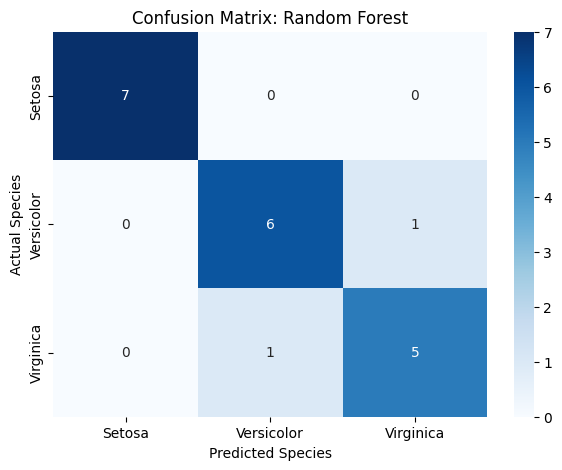

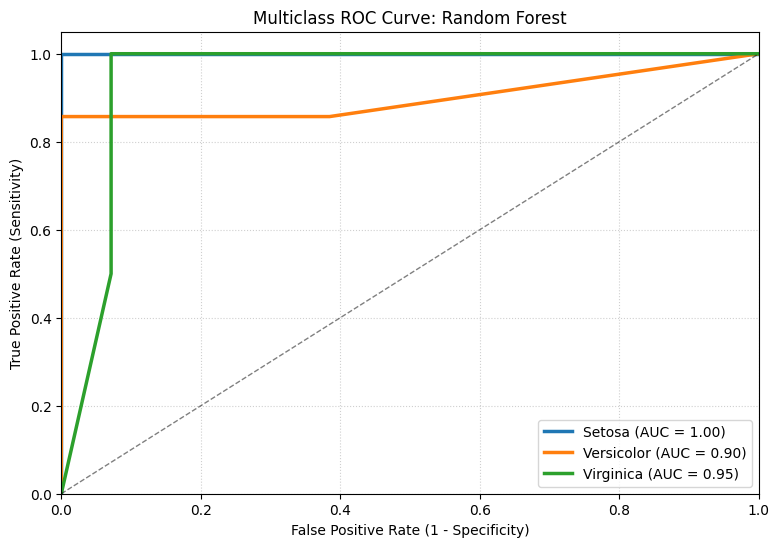

In [30]:
# ======================================================
# 4. Random Forest Result Analysis
# ======================================================

# Define your local folder path (Updated for Random Forest)
results_path = "Spark_Results/rf_result_2"
species_labels = ['Setosa', 'Versicolor', 'Virginica']

try:
    # A. Load Parquet
    table = pq.read_table(results_path)
    df_results = table.to_pandas()
    
    # B. Extract Data for Calculations
    y_true = df_results['label'].values
    y_pred = df_results['prediction'].values
    y_probs = extract_spark_probabilities(df_results)

    # C. FORMAT FOR TABLE DISPLAY
    # We create a clean version for the table view
    display_df = df_results[['label', 'prediction']].copy()
    
    # Format probabilities to a list of floats
    display_df['probability'] = [list(np.round(p, 10)) for p in y_probs]

    print(f"\n==================================================")
    print(f"INSPECTING TUNED RESULTS: {results_path}")
    print(f"==================================================")
    
    # Renders the interactive table
    display(display_df.head(20)) 
    
    print(f"==================================================\n")

    # D. Visualize Graphs
    plot_confusion_matrix(y_true, y_pred, species_labels, "Random Forest")
    plot_multiclass_roc(y_true, y_probs, species_labels, "Random Forest")

except Exception as e:
    print(f"An error occurred: {e}")


INSPECTING TUNED RESULTS: Spark_Results/nb_result_2


,label,prediction,probability
0,0.0,0.0,"[0.4010091027, 0.3019007615, 0.2970901358]"
1,0.0,0.0,"[0.4143833125, 0.2957856796, 0.2898310079]"
2,0.0,0.0,"[0.4354258001, 0.2863950052, 0.2781791946]"
3,0.0,0.0,"[0.4138630719, 0.2970739054, 0.2890630227]"
4,1.0,2.0,"[0.2432038805, 0.3724861946, 0.384309925]"
5,0.0,0.0,"[0.4607364587, 0.2758816276, 0.2633819137]"
6,0.0,0.0,"[0.4881158075, 0.2633524622, 0.2485317302]"
7,0.0,0.0,"[0.4758135814, 0.2697394702, 0.2544469485]"
8,1.0,2.0,"[0.232045647, 0.378720296, 0.389234057]"
9,1.0,2.0,"[0.2288795195, 0.3805484064, 0.3905720741]"


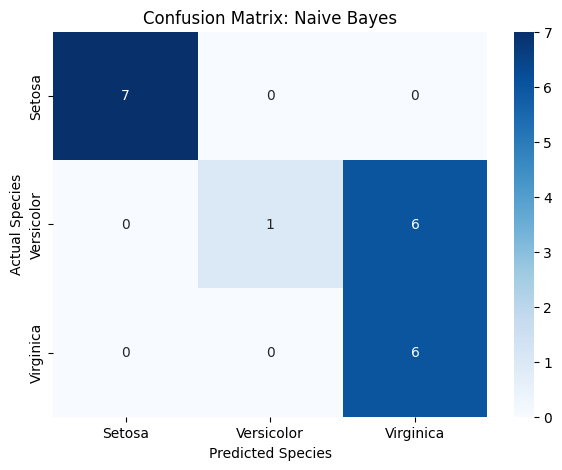

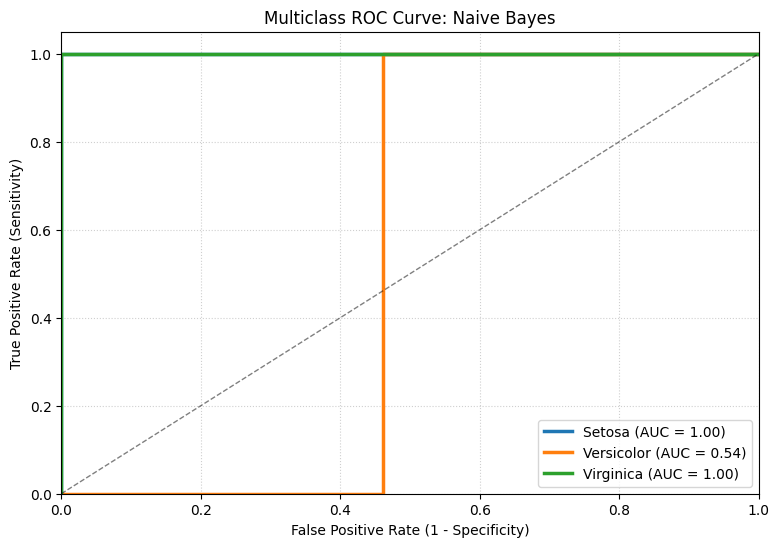

In [31]:
# ======================================================
# 5. Naive Bayes Result Analysis
# ======================================================

# Define your local folder path (Updated for Naive Bayes)
results_path = "Spark_Results/nb_result_2"
species_labels = ['Setosa', 'Versicolor', 'Virginica']

try:
    # A. Load Parquet
    table = pq.read_table(results_path)
    df_results = table.to_pandas()
    
    # B. Extract Data for Calculations
    y_true = df_results['label'].values
    y_pred = df_results['prediction'].values
    y_probs = extract_spark_probabilities(df_results)

    # C. FORMAT FOR TABLE DISPLAY
    # We create a clean version for the table view
    display_df = df_results[['label', 'prediction']].copy()
    
    # Format probabilities to a list of floats
    display_df['probability'] = [list(np.round(p, 10)) for p in y_probs]

    print(f"\n==================================================")
    print(f"INSPECTING TUNED RESULTS: {results_path}")
    print(f"==================================================")
    
    # Renders the interactive table
    display(display_df.head(20)) 
    
    print(f"==================================================\n")

    # D. Visualize Graphs
    plot_confusion_matrix(y_true, y_pred, species_labels, "Naive Bayes")
    plot_multiclass_roc(y_true, y_probs, species_labels, "Naive Bayes")

except Exception as e:
    print(f"An error occurred: {e}")